# 1 Importing and Merging Dataset

In [1]:
# import pandas as pd
# from pathlib import Path

# folder = Path(r"C:\Vrije University\Vrije University\VU\P6\Machine Learning for the Quantified Self\ML4QS\final_dfs")

# dfs = []

# for file in folder.glob("*.csv"):
#     print("Loading:", file)
#     dfs.append(pd.read_csv(file))

# print("Loaded files:", len(dfs))

In [2]:
# all_df = pd.concat(dfs, ignore_index=True)

# print(all_df.shape)
# corr = all_df.corr(numeric_only=True)
# print(corr)

In [3]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,6))
# plt.imshow(corr)
# plt.colorbar()
# plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
# plt.yticks(range(len(corr.columns)), corr.columns)
# plt.tight_layout()
# plt.show()

In [4]:
# print(all_df.shape)
# print(all_df.info())

In [5]:
# all_df.isnull().sum()

In [6]:
# all_df.describe()

In [7]:
# all_df["heart_rate"].hist()

In [8]:
# all_df["stress"].hist()

# EDA (with full_df)

In [9]:
import pandas as pd
from fitparse import FitFile
from collections import Counter
from pathlib import Path
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt

#eda1: Dataset overview:

In [10]:

full_df = pd.read_csv("../final_dfs/full_df.csv")

# Inspection of structure, types, and sample rows
print(full_df.shape)
print(full_df.info())
print(full_df.head())


(11520, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11520 entries, 0 to 11519
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         11520 non-null  object 
 1   stress            10358 non-null  float64
 2   body_battery      11146 non-null  float64
 3   respiration_rate  9171 non-null   float64
 4   heart_rate        9301 non-null   float64
 5   sleep_level       11520 non-null  object 
 6   sleep_score       7462 non-null   float64
 7   activity_type     10383 non-null  object 
 8   is_cognitive      11520 non-null  int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 810.1+ KB
None
             timestamp  stress  body_battery  respiration_rate  heart_rate  \
0  2026-06-03 00:00:00     NaN           NaN               NaN         NaN   
1  2026-06-03 00:01:00    12.0          32.0             13.58         NaN   
2  2026-06-03 00:02:00    20.0          32.0             15.3

#EDA2: checking for missing val: We assess data completeness to understand sensor reliability and potential bias in physiological signals.

In [11]:

val_missing = (full_df.isna().sum().sort_values(ascending=False))
print(val_missing)

sleep_score         4058
respiration_rate    2349
heart_rate          2219
stress              1162
activity_type       1137
body_battery         374
timestamp              0
sleep_level            0
is_cognitive           0
dtype: int64


In [12]:
# Converting nan counts into percentages for interpretability
missing_pct = (full_df.isna().mean() * 100).round(2)
print(missing_pct)

timestamp            0.00
stress              10.09
body_battery         3.25
respiration_rate    20.39
heart_rate          19.26
sleep_level          0.00
sleep_score         35.23
activity_type        9.87
is_cognitive         0.00
dtype: float64


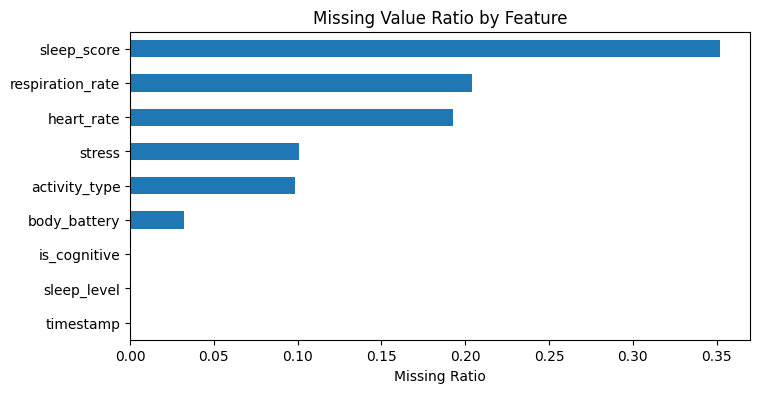

In [13]:
# plotting missingness across features
missing_ratio = full_df.isna().mean().sort_values()

plt.figure(figsize=(8, 4))
missing_ratio.plot(kind="barh")
plt.title("Missing Value Ratio by Feature")
plt.xlabel("Missing Ratio")
plt.show()

EDA3: checking for class imbalance: We evaluate class imbalance since cognitive periods represent a minority of the dataset.

In [14]:
# checking the distribution of cognitive vs non cognitive mins
full_df["is_cognitive"].value_counts()

is_cognitive
0    9596
1    1924
Name: count, dtype: int64

In [15]:
#Normalizing class distribution to check imbalance
full_df["is_cognitive"].value_counts(normalize=True)

is_cognitive
0    0.832986
1    0.167014
Name: proportion, dtype: float64

Feature Overview: We summarize physiological variables to understand baseline ranges and variability.

In [16]:
#EDA4: checking for physiological variables
physiological_features = [
    "stress",
    "body_battery",
    "heart_rate",
    "respiration_rate"
]
full_df[physiological_features].describe()

,stress,body_battery,heart_rate,respiration_rate
count,10358.000000,11146.000000,9301.000000,9171.000000
mean,22.376134,59.667055,70.033975,14.348578
std,22.583732,21.902270,16.280463,2.493534
min,-2.000000,21.000000,0.000000,0.000000
25%,6.000000,40.000000,57.000000,13.000000
50%,17.000000,59.000000,66.000000,14.580000
75%,31.000000,78.000000,79.000000,15.900000
max,99.000000,100.000000,172.000000,23.660000


Distribution Analysis: We visually compare distributions of physiological signals between cognitive and non-cognitive periods.

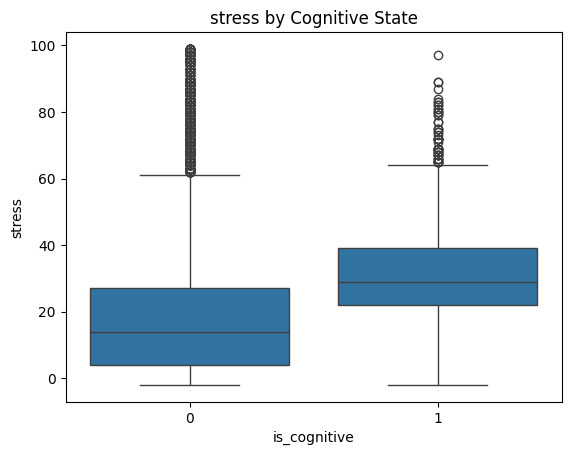

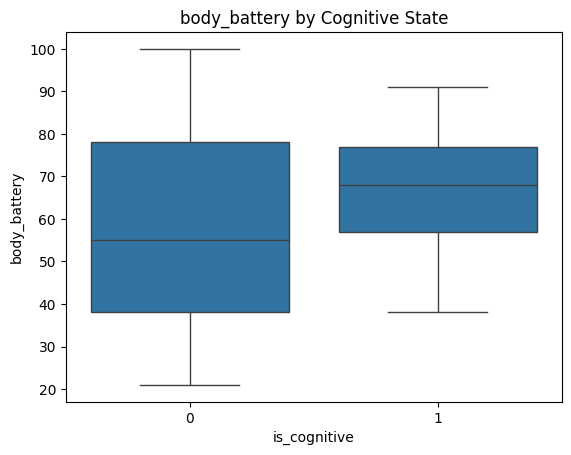

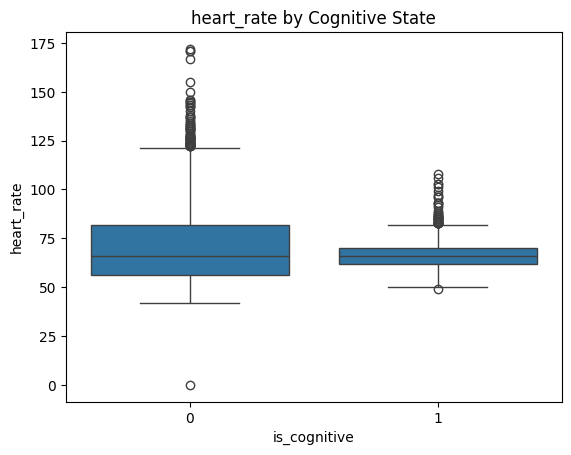

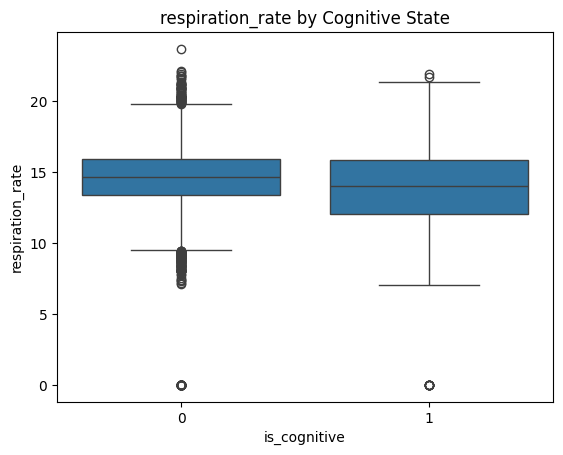

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

features = physiological_features

# Compare distributions across cognitive states
for col in features:
    plt.figure()
    sns.boxplot(data=full_df, x="is_cognitive", y=col)
    plt.title(f"{col} by Cognitive State")
    plt.show()

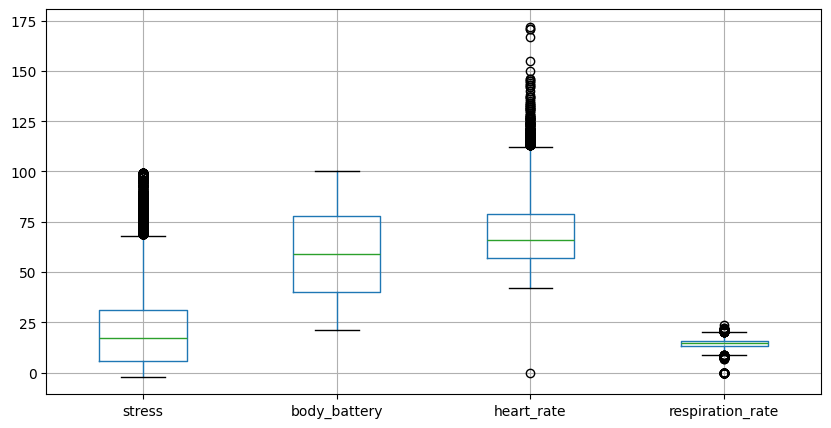

In [18]:
full_df[physiological_features].boxplot(figsize=(10,5))
plt.show()

Group Statistics: We quantify differences in central tendency and variability between cognitive and non-cognitive states.

In [19]:
# Compare average physiological signals between classes
full_df.groupby("is_cognitive")[physiological_features].mean()

,stress,body_battery,heart_rate,respiration_rate
is_cognitive,,,,
0,20.472138,58.339914,70.762410,14.467109
1,31.332048,66.224947,66.695678,13.885802


In [20]:
# Compare variability (standard deviation) between classes
full_df.groupby("is_cognitive")[physiological_features].agg(["mean", "std"])

stress            body_battery            heart_rate  \
                   mean        std         mean        std       mean   
is_cognitive                                                            
0             20.472138  23.522493    58.339914  23.115031  70.762410   
1             31.332048  14.467647    66.224947  12.583271  66.695678   

                        respiration_rate            
                    std             mean       std  
is_cognitive                                        
0             17.585202        14.467109  2.394258  
1              7.002647        13.885802  2.801277

Distribution Shape: We evaluate separability of classes by inspecting distribution overlap.

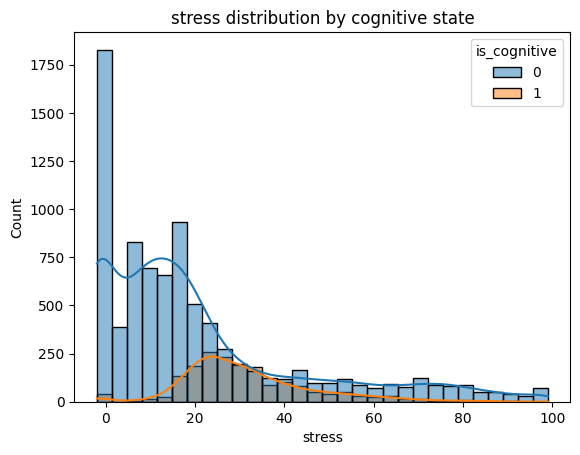

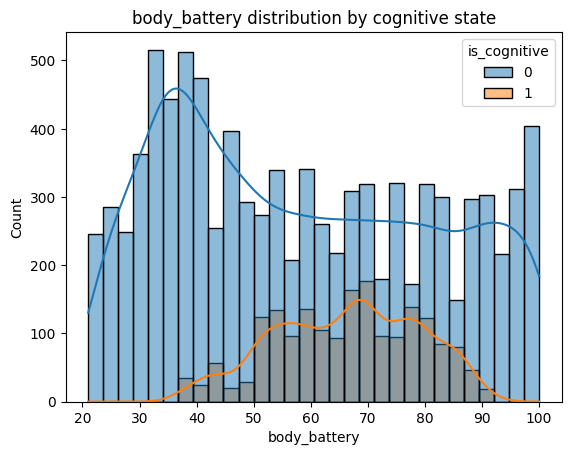

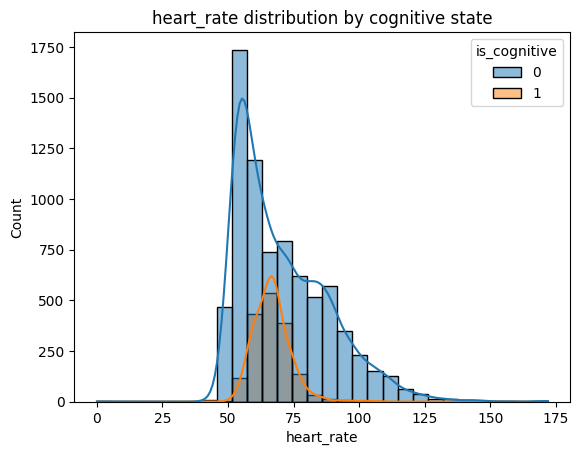

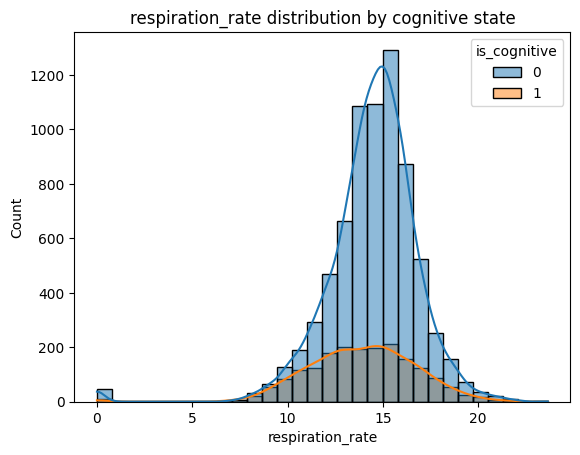

In [21]:
# Check overlap between distributions using histograms
for col in features:
    plt.figure()
    sns.histplot(
        data=full_df,
        x=col,
        hue="is_cognitive",
        kde=True,
        bins=30
    )
    plt.title(f"{col} distribution by cognitive state")
    plt.show()

Effect Size: COHEN’S D (We compute effect sizes to quantify how strongly physiological signals differ between conditions.)

In [22]:
from statistics import mean, stdev
from math import sqrt

def cohens_d(x1, x0):
    return (mean(x1) - mean(x0)) / sqrt((stdev(x1)**2 + stdev(x0)**2) / 2)

for col in features:
    group1 = full_df.loc[full_df["is_cognitive"] == 1, col].dropna()
    group0 = full_df.loc[full_df["is_cognitive"] == 0, col].dropna()
    
    d = cohens_d(group1, group0)
    print(col, d)

stress 0.5561436944087872
body_battery 0.42370508120217304
heart_rate -0.30384453080630497
respiration_rate -0.22308804646623137


Time-of-day bias

In [23]:
full_df["timestamp"] = pd.to_datetime(full_df["timestamp"])

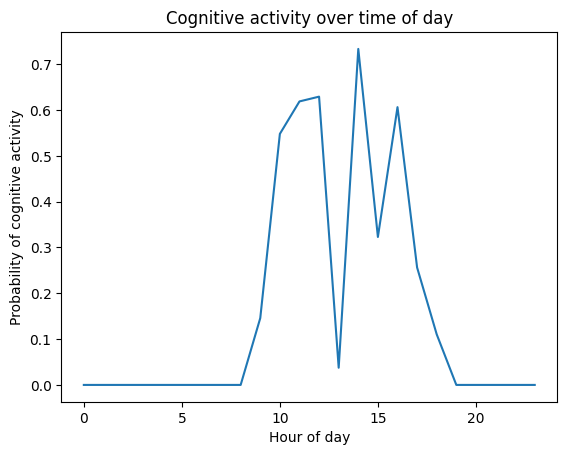

In [24]:
# Checking whether  the cognitive tasks are concentrated at specific hours??
full_df["hour"] = full_df["timestamp"].dt.hour

full_df.groupby("hour")["is_cognitive"].mean().plot()
plt.title("Cognitive activity over time of day")
plt.xlabel("Hour of day")
plt.ylabel("Probability of cognitive activity")
plt.show()

Activity confounding check: in order to prove that  signals are not just sedentary vs active classification!!

In [25]:
# Checking whether cognitive periods overlap with specific activities
pd.crosstab(full_df["activity_type"], full_df["is_cognitive"]) 


is_cognitive,0,1
activity_type,,
cycling,367,0
generic,2920,1280
running,67,1
sedentary,4729,643
unknown,45,0
walking,331,0


Correlation analysis

In [26]:
# Checking correlation between physiological signals and cognitive state
corr = full_df[physiological_features + ["is_cognitive"]].corr()
corr["is_cognitive"].sort_values()

heart_rate         -0.095789
respiration_rate   -0.093931
body_battery        0.134701
stress              0.182858
is_cognitive        1.000000
Name: is_cognitive, dtype: float64

Missingness vs target: to check if missing data is biased toward one class

In [27]:
# Checking if missing data is biased toward one class
full_df.isna().groupby(full_df["is_cognitive"]).mean()

,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_level,sleep_score,activity_type,is_cognitive,hour
is_cognitive,,,,,,,,,,
0,0.0,0.109837,0.033972,0.239162,0.204356,0.0,0.422885,0.118487,0.0,0.0
1,0.0,0.056133,0.024948,0.028067,0.134096,0.0,0.000000,0.000000,0.0,0.0


Time plots:

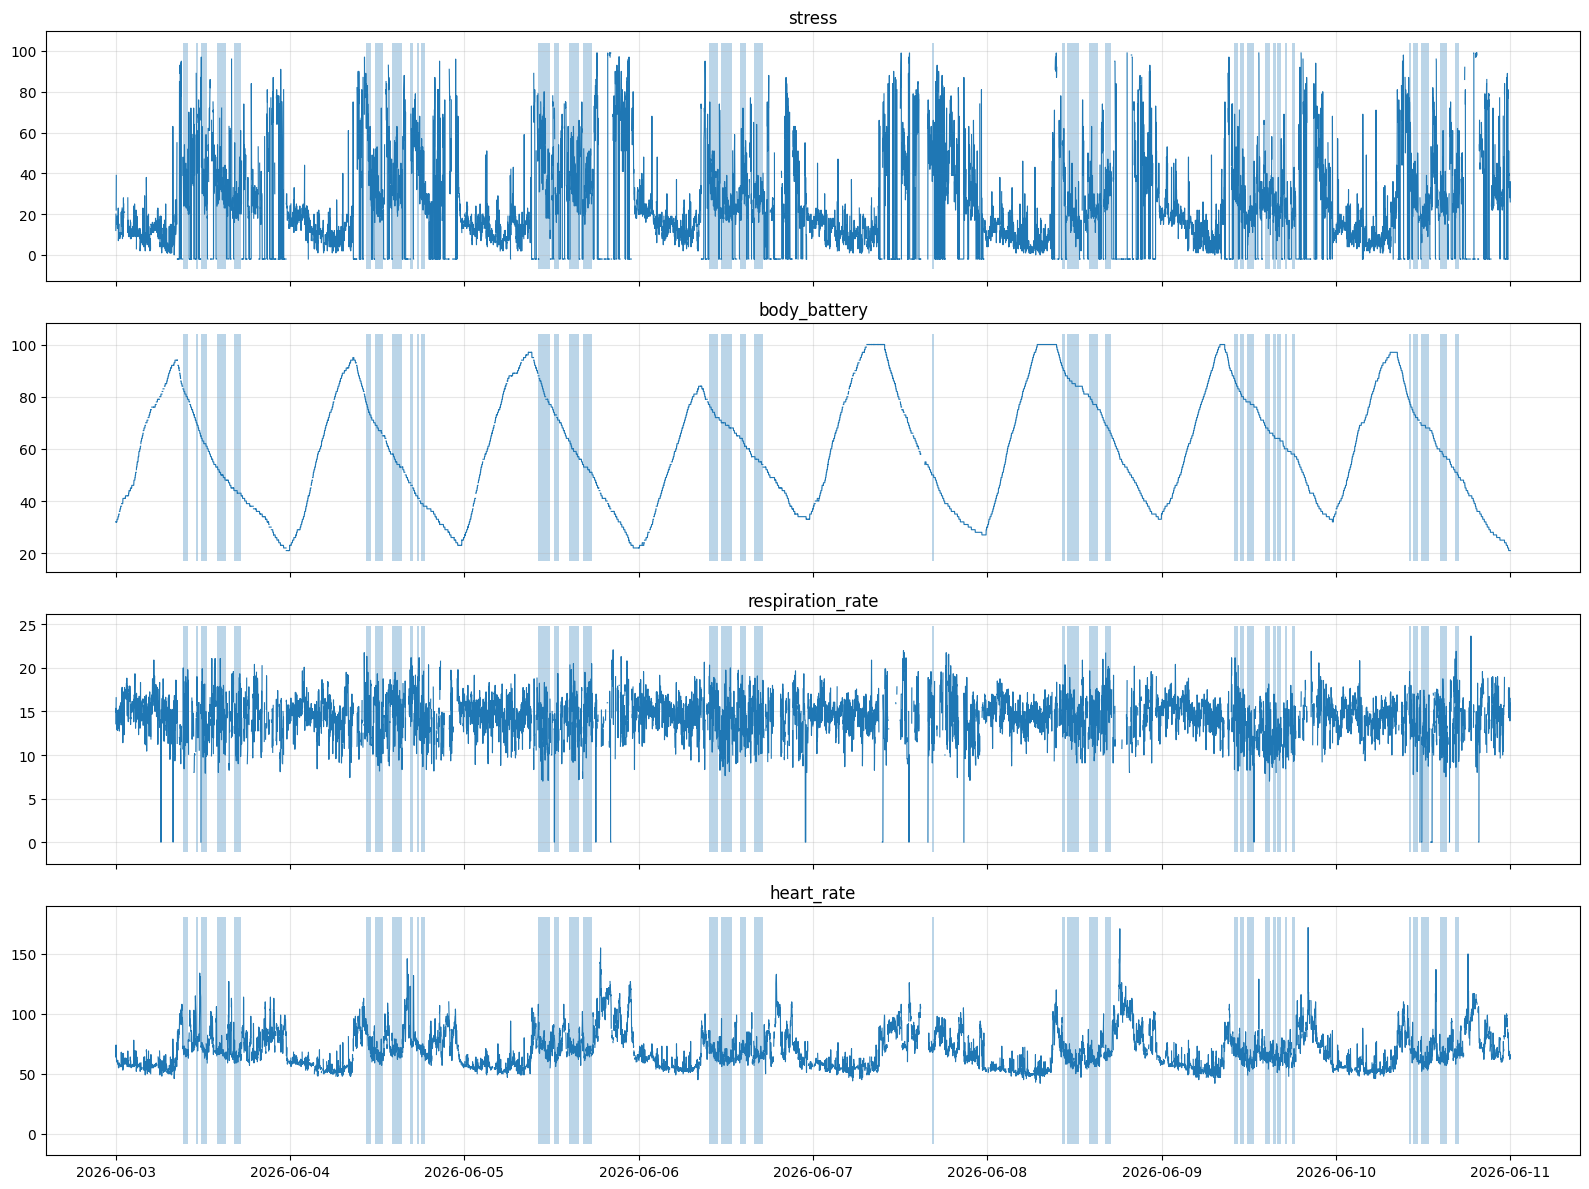

In [28]:
full_df["timestamp"] = pd.to_datetime(full_df["timestamp"])

fig, axes = plt.subplots(
    4, 1,
    figsize=(16, 12),
    sharex=True
)

features = [
    "stress",
    "body_battery",
    "respiration_rate",
    "heart_rate"
]

for ax, feature in zip(axes, features):

    ax.plot(
        full_df["timestamp"],
        full_df[feature],
        linewidth=0.8
    )

    # shade cognitive periods
    cognitive = full_df["is_cognitive"] == 1

    ax.fill_between(
        full_df["timestamp"],
        ax.get_ylim()[0],
        ax.get_ylim()[1],
        where=cognitive,
        alpha=0.3
    )

    ax.set_title(feature)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

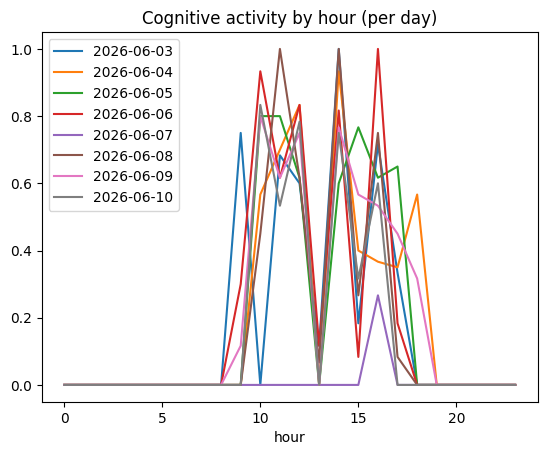

In [29]:
# Compare cognitive activity patterns per day
full_df["date"] = full_df["timestamp"].dt.date

for d in full_df["date"].unique():
    temp = full_df[full_df["date"] == d]
    
    temp.groupby("hour")["is_cognitive"].mean().plot(label=str(d))

plt.legend()
plt.title("Cognitive activity by hour (per day)")
plt.show()

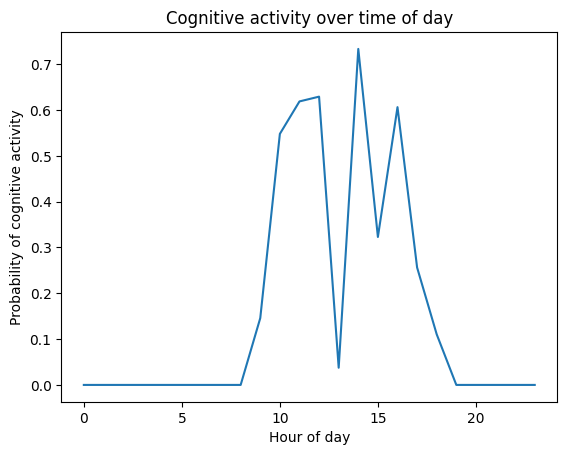

In [30]:
# Check whether cognitive tasks are concentrated at specific hours -> Average probability of cognitive activity at each hour across all 3 days
full_df["hour"] = full_df["timestamp"].dt.hour

full_df.groupby("hour")["is_cognitive"].mean().plot()
plt.title("Cognitive activity over time of day")
plt.xlabel("Hour of day")
plt.ylabel("Probability of cognitive activity")
plt.show()